#  Botnet DDoS Detection — Data Analysis Notebook
**Author:** Person 5 — Analysis, Detection & Defense  
**Dataset:** `windows_1s_all.csv` — 1-second sliding-window network traffic features  

---

##  Purpose
This notebook explores the preprocessed dataset produced by the C2 capture preprocessing pipeline.  
It covers:
1. Loading and inspecting the data
2. Exploring key traffic features (pps, bps, packet_count, burstiness, etc.)
3. Visualising time-series behaviour and class distributions
4. Building a correlation heatmap to understand feature relationships
5. Generating and saving all plots to `analysis/plots/`

---

##  How to Run
```bash
# From the repo root:
cd analysis
jupyter notebook analysis.ipynb
# OR open with VS Code's Jupyter extension
```
Run all cells top-to-bottom with **Kernel → Restart & Run All**.

In [17]:
# ============================================================
# CELL 1 — Imports & configuration
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# --- Paths ---
BASE_DIR  = os.getcwd()                          
DATA_PATH = os.path.join(BASE_DIR, "../dataset/processed/windows_1s_all.csv")
PLOTS_DIR = os.path.join(BASE_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- Plot style ---
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Helper: save + show
def save(fig, filename):
    """Save a matplotlib figure to analysis/plots/ and display it inline."""
    path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(path, bbox_inches='tight')
    print(f'   Saved → {path}')
    plt.show()

print('Imports OK.  Plots will be saved to:', PLOTS_DIR)

Imports OK.  Plots will be saved to: c:\Users\pc\CNS_Project_C1\Behavioral-Analysis-and-Detection-of-Simulated-Botnet-Based-DDoS-Traffic\analysis\plots


---
## Load & Inspect the Dataset

In [18]:
# ============================================================
# CELL 2 — Load dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print(f'Shape  : {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Shape  : 10,544 rows  ×  48 columns
Memory : 6.4 MB


,capture_id,scenario_id,window_start_time,window_duration,relative_time,attack_start_time,phase,attack_family,packet_count,byte_count,...,unique_src_mean_5s,flow_count_mean_5s,pps_slope_5s,bps_slope_5s,unique_src_slope_5s,flow_count_slope_5s,pps_zscore,bps_zscore,unique_src_zscore,flow_count_zscore
0,c2__http-high__60s__20260505_114315__R1_egress,http-high,1.777971e+09,1.0,0.0,1.777971e+09,normal,http,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,c2__http-high__60s__20260505_114315__R1_egress,http-high,1.777971e+09,1.0,1.0,1.777971e+09,normal,http,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,c2__http-high__60s__20260505_114315__R1_egress,http-high,1.777971e+09,1.0,2.0,1.777971e+09,normal,http,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# ============================================================
# CELL 3 — Label distributions
# ============================================================
# `phase`         is the PRIMARY label  (what stage of an attack are we in?)
# `attack_family` is the SECONDARY label (which botnet protocol is attacking?)

print('=== phase (primary label) ===')
print(df['phase'].value_counts())

print('\n=== attack_family (secondary label) ===')
print(df['attack_family'].value_counts())

=== phase (primary label) ===
phase
attack         5280
normal         2696
post_attack    1688
pre_attack      880
Name: count, dtype: int64

=== attack_family (secondary label) ===
attack_family
udp      2648
tcp      2600
http     2592
none      976
icmp      864
mixed     864
Name: count, dtype: int64


In [20]:
# ============================================================
# CELL 4 — Basic statistics for numeric features
# ============================================================
# .describe() gives count, mean, std, min, quartiles, max for every column.
# Transpose (.T) so each feature is a row — easier to read.

numeric_cols = df.select_dtypes(include='number').columns.tolist()
df[numeric_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
window_start_time,10544.0,1.777970e+09,702.332,1.777969e+09,1.777970e+09,1.777970e+09,1.777971e+09,1.777972e+09
window_duration,10544.0,1.000000e+00,0.000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
relative_time,10544.0,5.449500e+01,31.849,0.000000e+00,2.700000e+01,5.400000e+01,8.200000e+01,1.210000e+02
attack_start_time,9568.0,1.777970e+09,461.560,1.777969e+09,1.777970e+09,1.777970e+09,1.777971e+09,1.777971e+09
packet_count,10544.0,8.223290e+02,1381.488,0.000000e+00,0.000000e+00,4.000000e+00,1.403000e+03,1.379200e+04
byte_count,10544.0,1.787319e+05,441947.391,0.000000e+00,0.000000e+00,3.920000e+02,1.152000e+05,2.904622e+06
pps,10544.0,8.223290e+02,1381.488,0.000000e+00,0.000000e+00,4.000000e+00,1.403000e+03,1.379200e+04
bps,10544.0,1.429855e+06,3535579.129,0.000000e+00,0.000000e+00,3.136000e+03,9.216000e+05,2.323698e+07
avg_packet_size,10544.0,1.039150e+02,167.374,0.000000e+00,0.000000e+00,6.400000e+01,1.010000e+02,5.558540e+02
tcp_packet_count,10544.0,4.537760e+02,1133.770,0.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01,1.379200e+04


In [21]:
# ============================================================
# CELL 5 — Missing values check
# ============================================================
# Rolling statistics (pps_mean_5s etc.) can be NaN for the first few
# rows of a capture before the window warms up.  We fill them with 0.

missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print('  No missing values found.')
else:
    print('  Missing values detected:')
    print(missing)
    df.fillna(0, inplace=True)
    print('   → Filled with 0.')

  Missing values detected:
attack_start_time    976
dtype: int64
   → Filled with 0.


---
## Class Distribution Plots
Understanding how balanced or imbalanced our labels are is critical before modelling.

   Saved → c:\Users\pc\CNS_Project_C1\Behavioral-Analysis-and-Detection-of-Simulated-Botnet-Based-DDoS-Traffic\analysis\plots\label_distributions.png


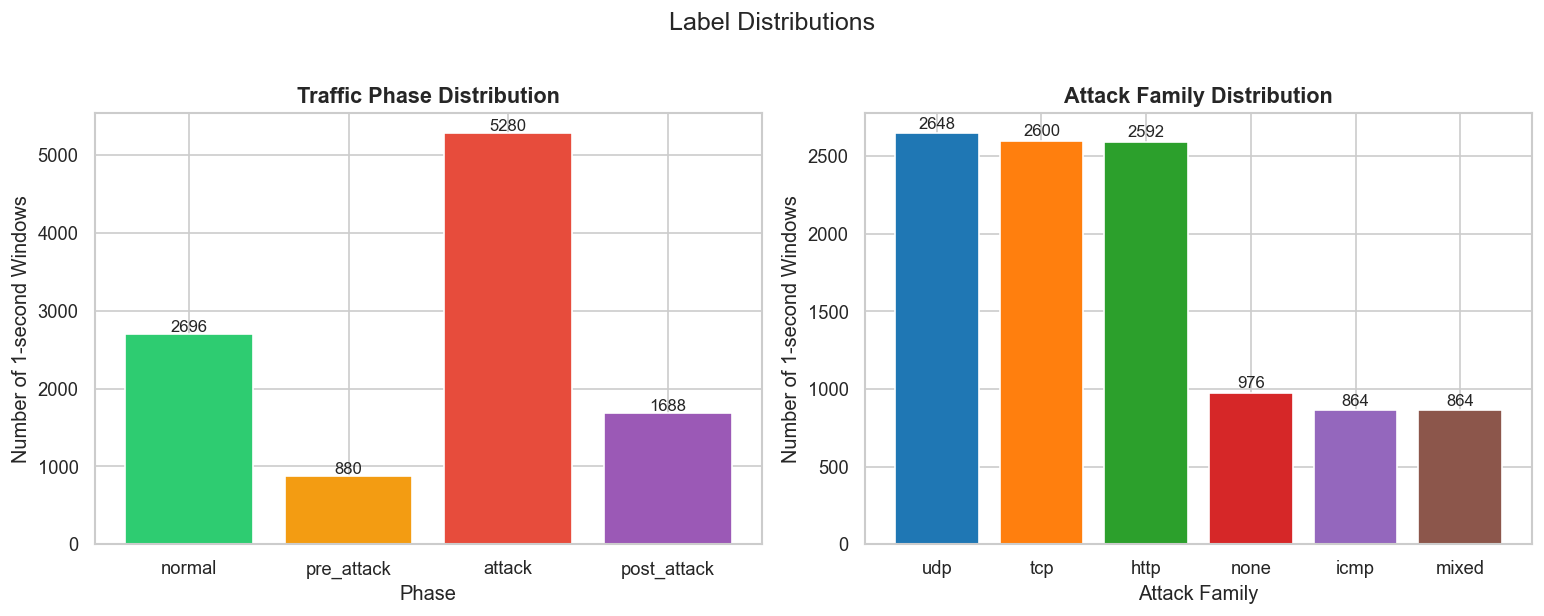

In [22]:
# ============================================================
# CELL 6 — Bar charts: phase  and  attack_family distributions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Phase ---
phase_order = ['normal', 'pre_attack', 'attack', 'post_attack']
phase_counts = df['phase'].value_counts().reindex(phase_order)
axes[0].bar(phase_counts.index, phase_counts.values,
            color=['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'])
axes[0].set_title('Traffic Phase Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Phase')
axes[0].set_ylabel('Number of 1-second Windows')
for i, v in enumerate(phase_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

# --- Attack family ---
fam_counts = df['attack_family'].value_counts()
axes[1].bar(fam_counts.index, fam_counts.values, color=sns.color_palette('tab10'))
axes[1].set_title('Attack Family Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attack Family')
axes[1].set_ylabel('Number of 1-second Windows')
for i, v in enumerate(fam_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=10)

plt.suptitle('Label Distributions', fontsize=15, y=1.02)
plt.tight_layout()
save(fig, 'label_distributions.png')

---
## Time-Series Plots: pps and bps over Relative Time
`relative_time` counts seconds from the start of each capture.  
We pick **one** capture and plot how packets-per-second (pps) and bits-per-second (bps) evolve through normal → pre-attack → attack → post-attack phases.

Using capture: c2__http-high__60s__20260505_114315__R1_egress
Rows: 108  |  Phases present: ['normal' 'pre_attack' 'attack' 'post_attack']
   Saved → c:\Users\pc\CNS_Project_C1\Behavioral-Analysis-and-Detection-of-Simulated-Botnet-Based-DDoS-Traffic\analysis\plots\pps_bps_over_time.png


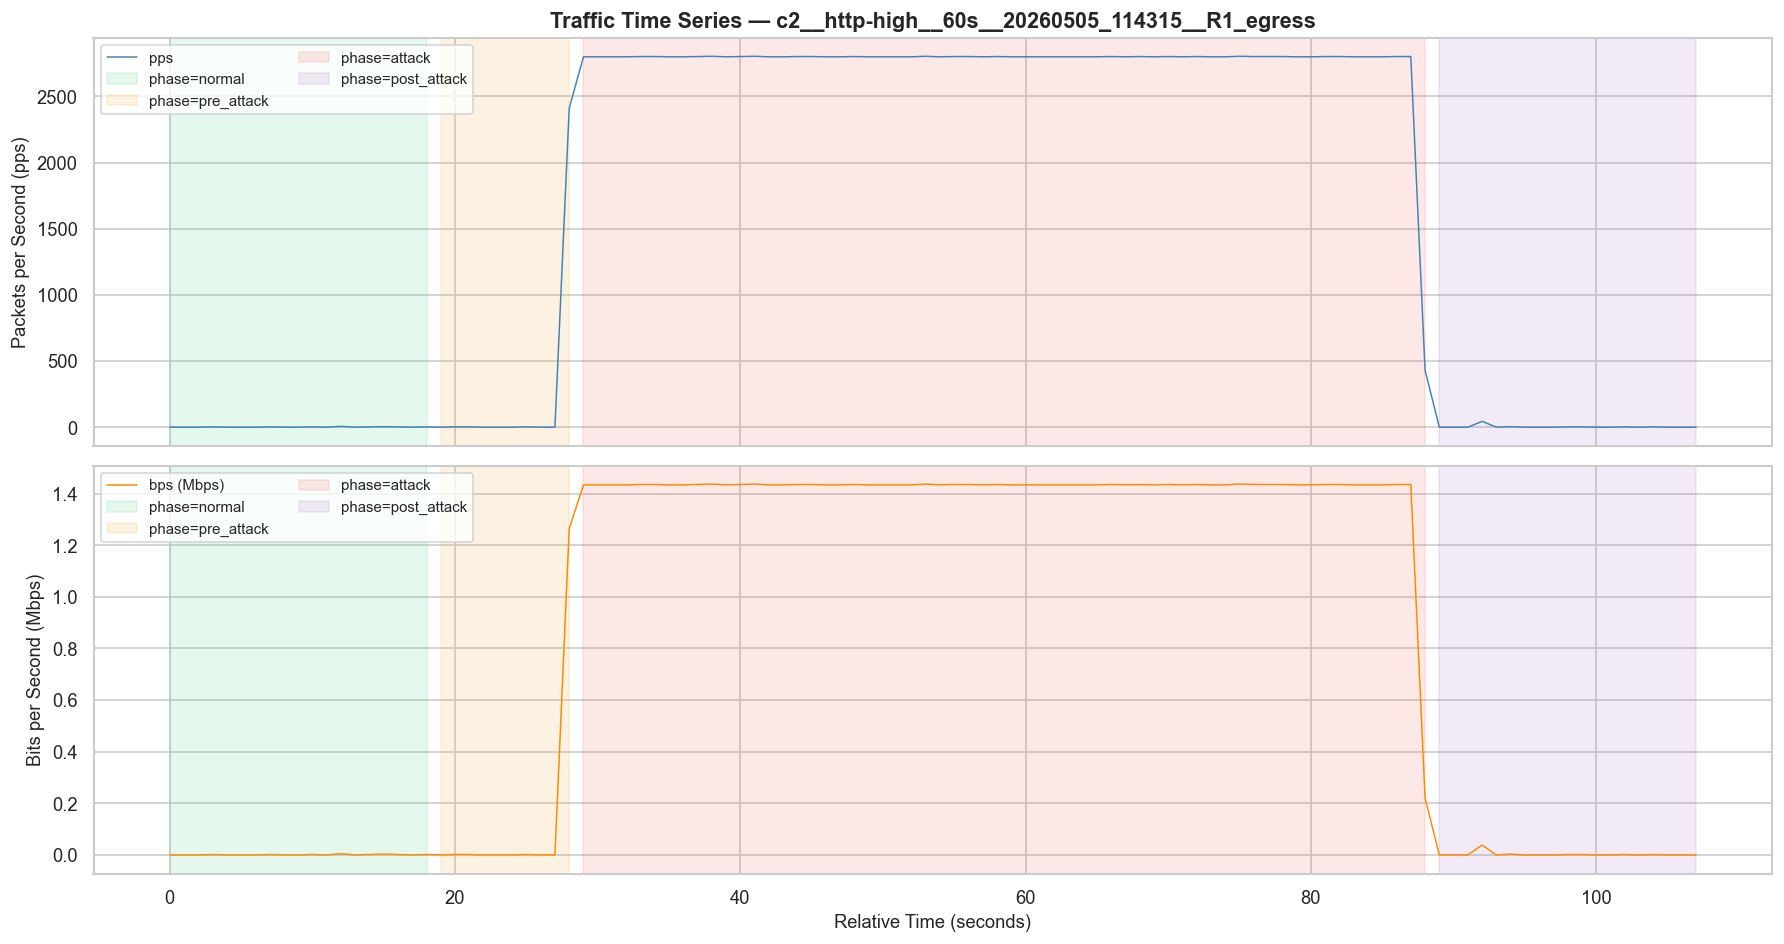

In [23]:
# ============================================================
# CELL 7 — Time series: pps and bps for a single capture
# ============================================================

# Pick the first capture that contains all 4 phases (most informative)
full_phase_captures = (
    df.groupby('capture_id')['phase']
    .nunique()
    .pipe(lambda s: s[s == 4])
    .index
)

if len(full_phase_captures) > 0:
    chosen_capture = full_phase_captures[0]
else:
    # Fallback: pick capture with the most rows
    chosen_capture = df['capture_id'].value_counts().index[0]

cap = df[df['capture_id'] == chosen_capture].sort_values('relative_time').copy()
print(f'Using capture: {chosen_capture}')
print(f'Rows: {len(cap)}  |  Phases present: {cap["phase"].unique()}')

# Colour map for phase bands
PHASE_COLOURS = {
    'normal':      '#2ecc71',
    'pre_attack':  '#f39c12',
    'attack':      '#e74c3c',
    'post_attack': '#9b59b6',
}

def add_phase_shading(ax, ts_df):
    """Shade background by phase so the reader can instantly see transitions."""
    for phase, colour in PHASE_COLOURS.items():
        mask = ts_df['phase'] == phase
        if mask.any():
            times = ts_df.loc[mask, 'relative_time'].values
            ax.axvspan(times.min(), times.max(), alpha=0.12,
                       color=colour, label=f'phase={phase}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# --- pps ---
ax1.plot(cap['relative_time'], cap['pps'], color='steelblue', linewidth=0.9, label='pps')
add_phase_shading(ax1, cap)
ax1.set_ylabel('Packets per Second (pps)', fontsize=11)
ax1.set_title(f'Traffic Time Series — {chosen_capture}', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, ncol=2)

# --- bps ---
ax2.plot(cap['relative_time'], cap['bps'] / 1e6, color='darkorange',
         linewidth=0.9, label='bps (Mbps)')
add_phase_shading(ax2, cap)
ax2.set_ylabel('Bits per Second (Mbps)', fontsize=11)
ax2.set_xlabel('Relative Time (seconds)', fontsize=11)
ax2.legend(loc='upper left', fontsize=9, ncol=2)

plt.tight_layout()
save(fig, 'pps_bps_over_time.png')

---
## Key Feature Distributions: Attack vs Normal
Box plots compare how each feature's value differs between phases.  
Features that clearly separate the phases are the most useful for detection.

   Saved → c:\Users\pc\CNS_Project_C1\Behavioral-Analysis-and-Detection-of-Simulated-Botnet-Based-DDoS-Traffic\analysis\plots\feature_distributions_by_phase.png


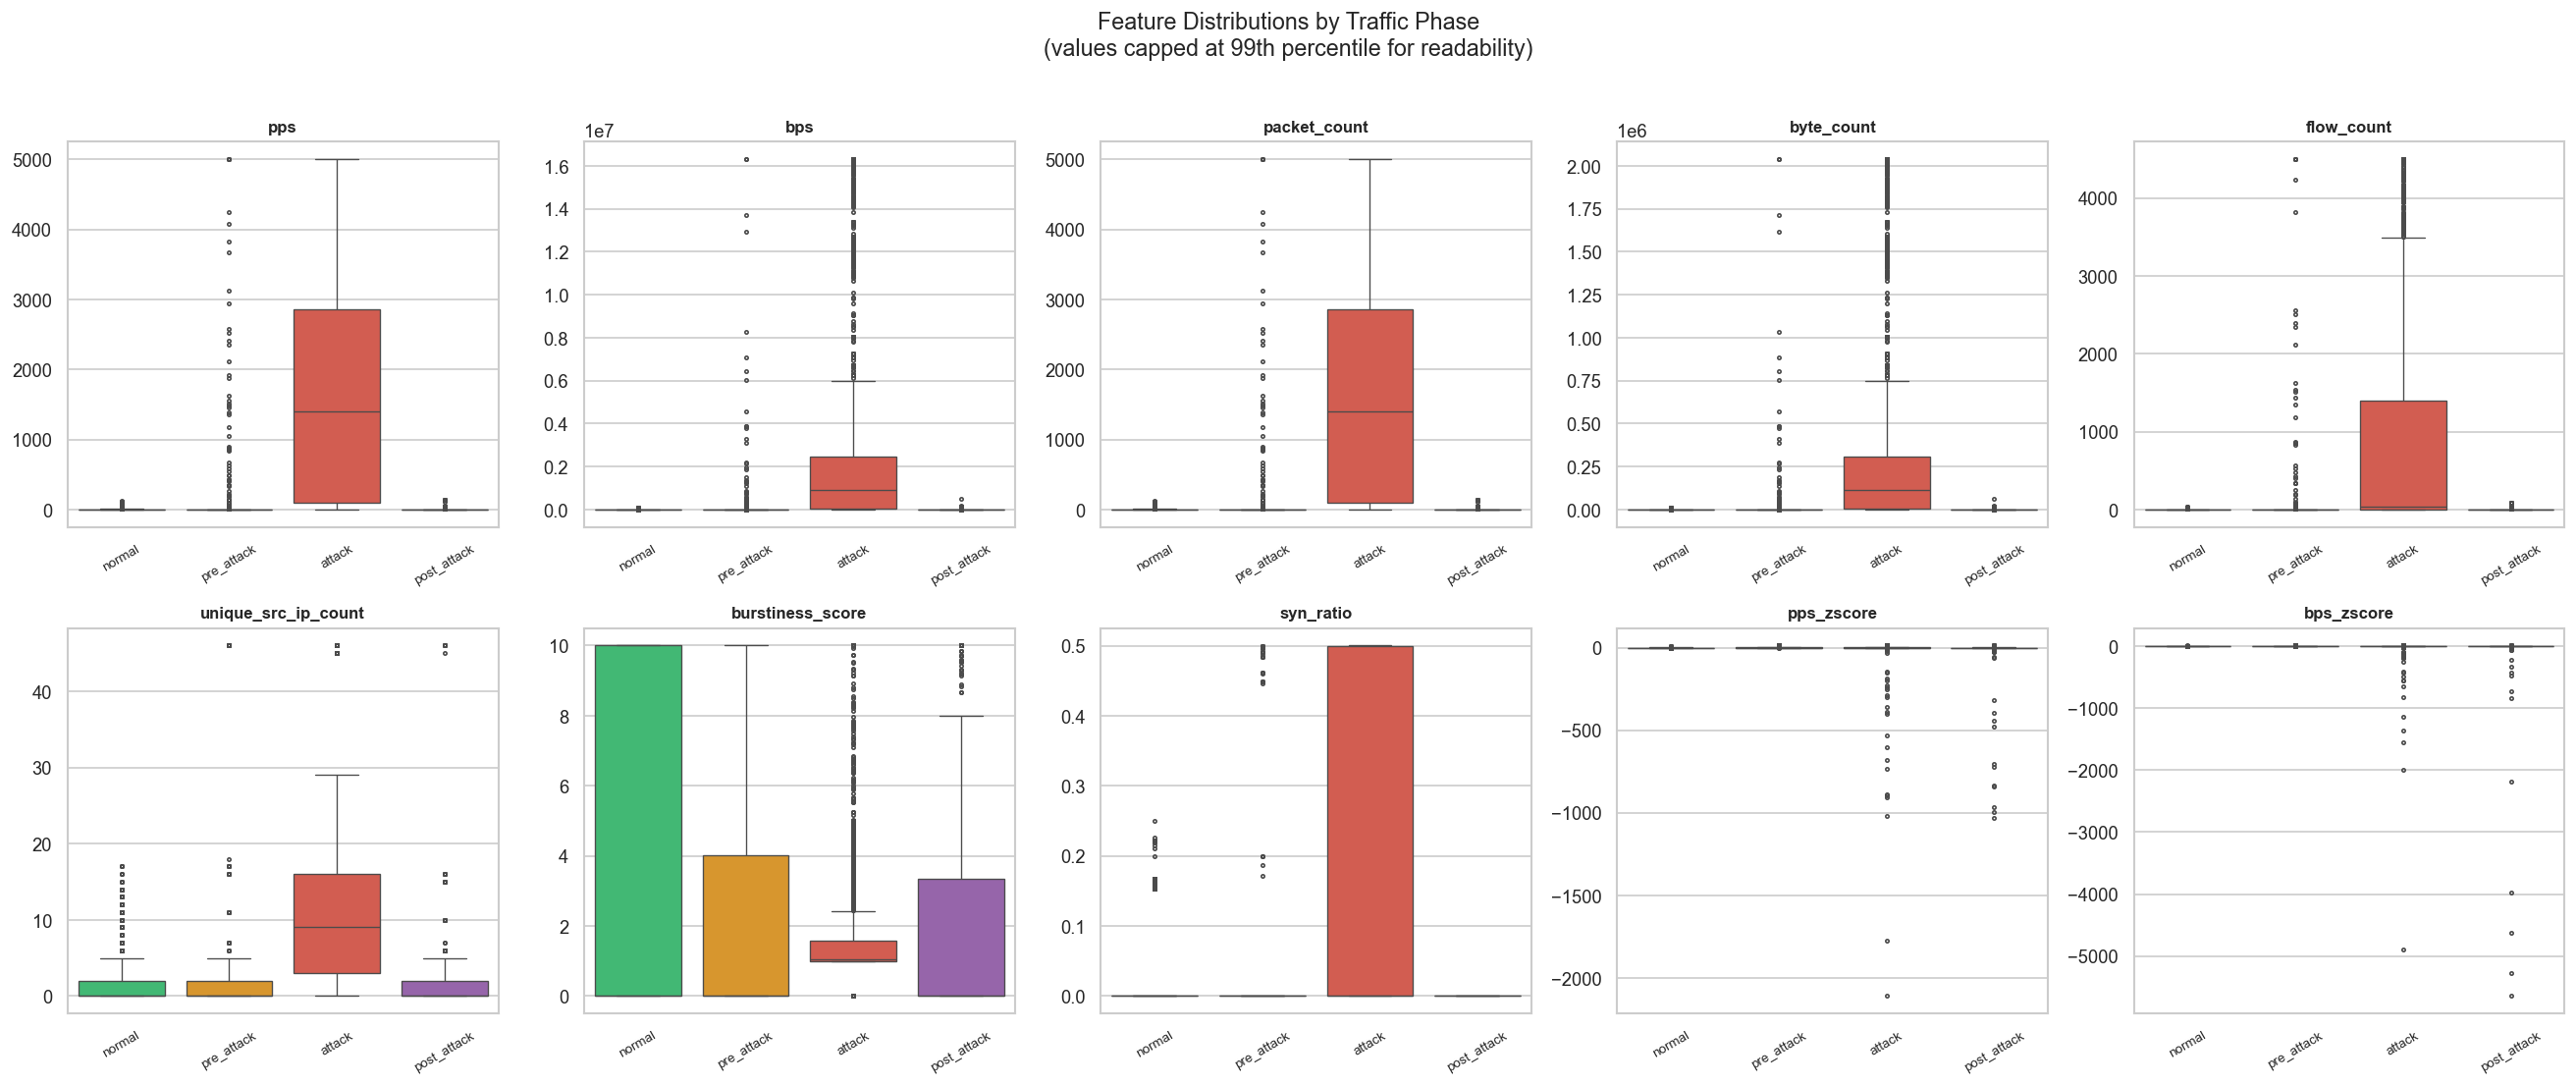

In [24]:
# ============================================================
# CELL 8 — Box plots: attack vs normal for important features
# ============================================================

KEY_FEATURES = [
    'pps', 'bps', 'packet_count', 'byte_count',
    'flow_count', 'unique_src_ip_count', 'burstiness_score',
    'syn_ratio', 'pps_zscore', 'bps_zscore',
]

# Clip extreme outliers at 99th percentile so box plots are readable
df_plot = df.copy()
for col in KEY_FEATURES:
    cap99 = df_plot[col].quantile(0.99)
    df_plot[col] = df_plot[col].clip(upper=cap99)

phase_order = ['normal', 'pre_attack', 'attack', 'post_attack']
palette = {p: PHASE_COLOURS[p] for p in phase_order}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, feat in enumerate(KEY_FEATURES):
    sns.boxplot(
        data=df_plot, x='phase', y=feat, order=phase_order,
        palette=palette, ax=axes[i], linewidth=0.8, fliersize=2,
    )
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle('Feature Distributions by Traffic Phase\n(values capped at 99th percentile for readability)',
             fontsize=14, y=1.02)
plt.tight_layout()
save(fig, 'feature_distributions_by_phase.png')

---
## Feature Distributions by Attack Family
Each botnet attack type (UDP flood, TCP SYN flood, HTTP flood, ICMP flood) has a distinct traffic signature.  
Here we compare pps and unique_src_ip_count across families.

   Saved → c:\Users\pc\CNS_Project_C1\Behavioral-Analysis-and-Detection-of-Simulated-Botnet-Based-DDoS-Traffic\analysis\plots\pps_unique_src_by_attack_family.png


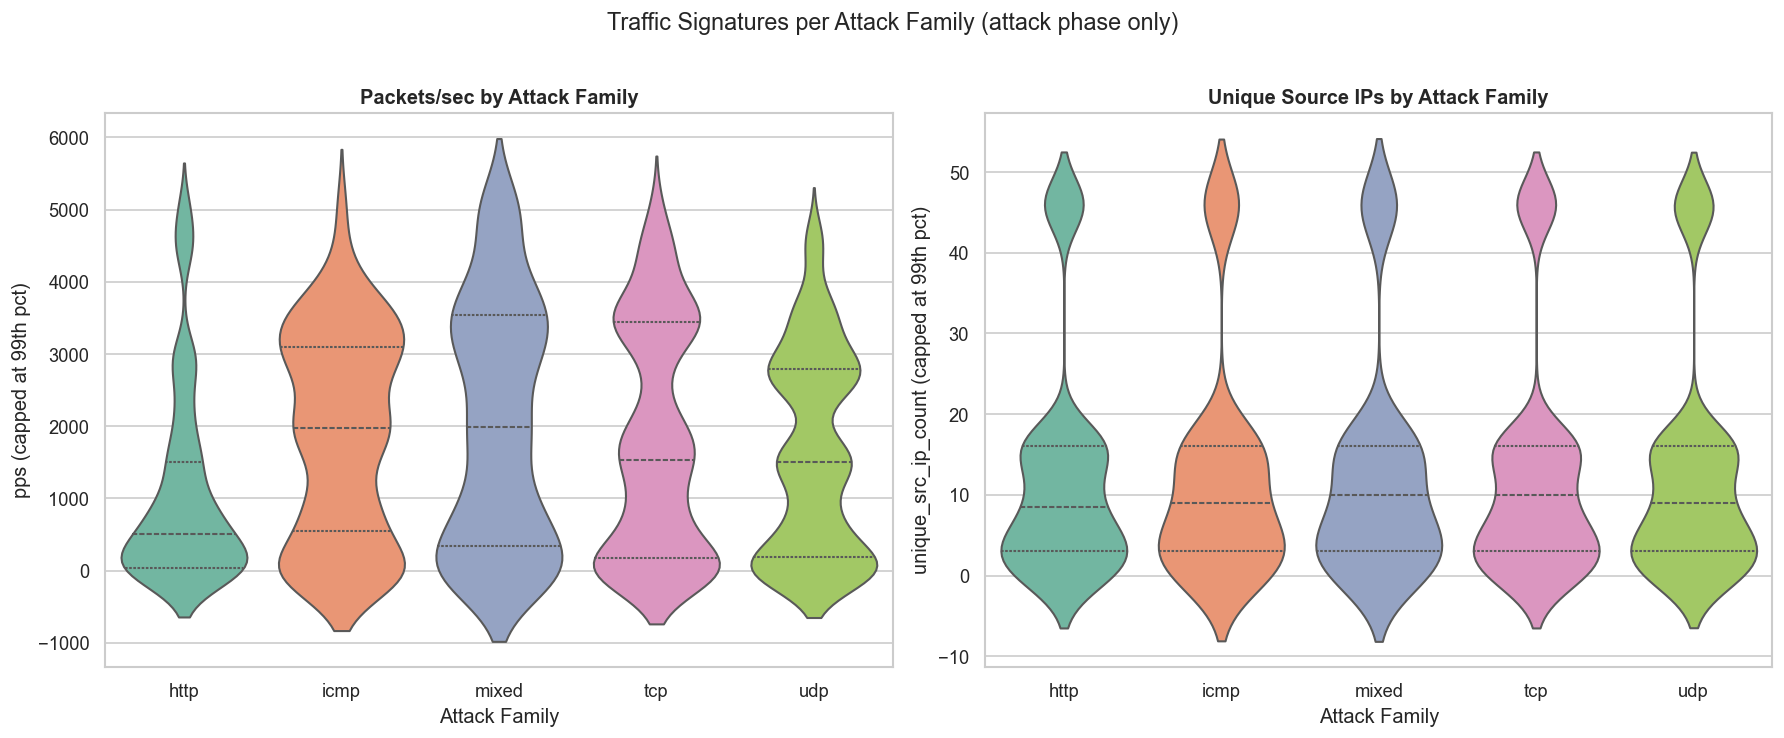

In [25]:
# ============================================================
# CELL 9 — Violin plots: pps & unique_src by attack family
# ============================================================

attack_only = df_plot[df_plot['phase'] == 'attack'].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.violinplot(data=attack_only, x='attack_family', y='pps',
               palette='Set2', ax=axes[0], inner='quartile')
axes[0].set_title('Packets/sec by Attack Family', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attack Family')
axes[0].set_ylabel('pps (capped at 99th pct)')

sns.violinplot(data=attack_only, x='attack_family', y='unique_src_ip_count',
               palette='Set2', ax=axes[1], inner='quartile')
axes[1].set_title('Unique Source IPs by Attack Family', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Attack Family')
axes[1].set_ylabel('unique_src_ip_count (capped at 99th pct)')

plt.suptitle('Traffic Signatures per Attack Family (attack phase only)',
             fontsize=14, y=1.02)
plt.tight_layout()
save(fig, 'pps_unique_src_by_attack_family.png')

---
## Correlation Heatmap
A Pearson correlation heatmap shows which features are linearly related.  
Highly correlated feature pairs (e.g. pps ↔ packet_count) contain redundant information — useful to know when selecting features for a lightweight detector.

   Saved → c:\Users\pc\CNS_Project_C1\Behavioral-Analysis-and-Detection-of-Simulated-Botnet-Based-DDoS-Traffic\analysis\plots\correlation_heatmap.png


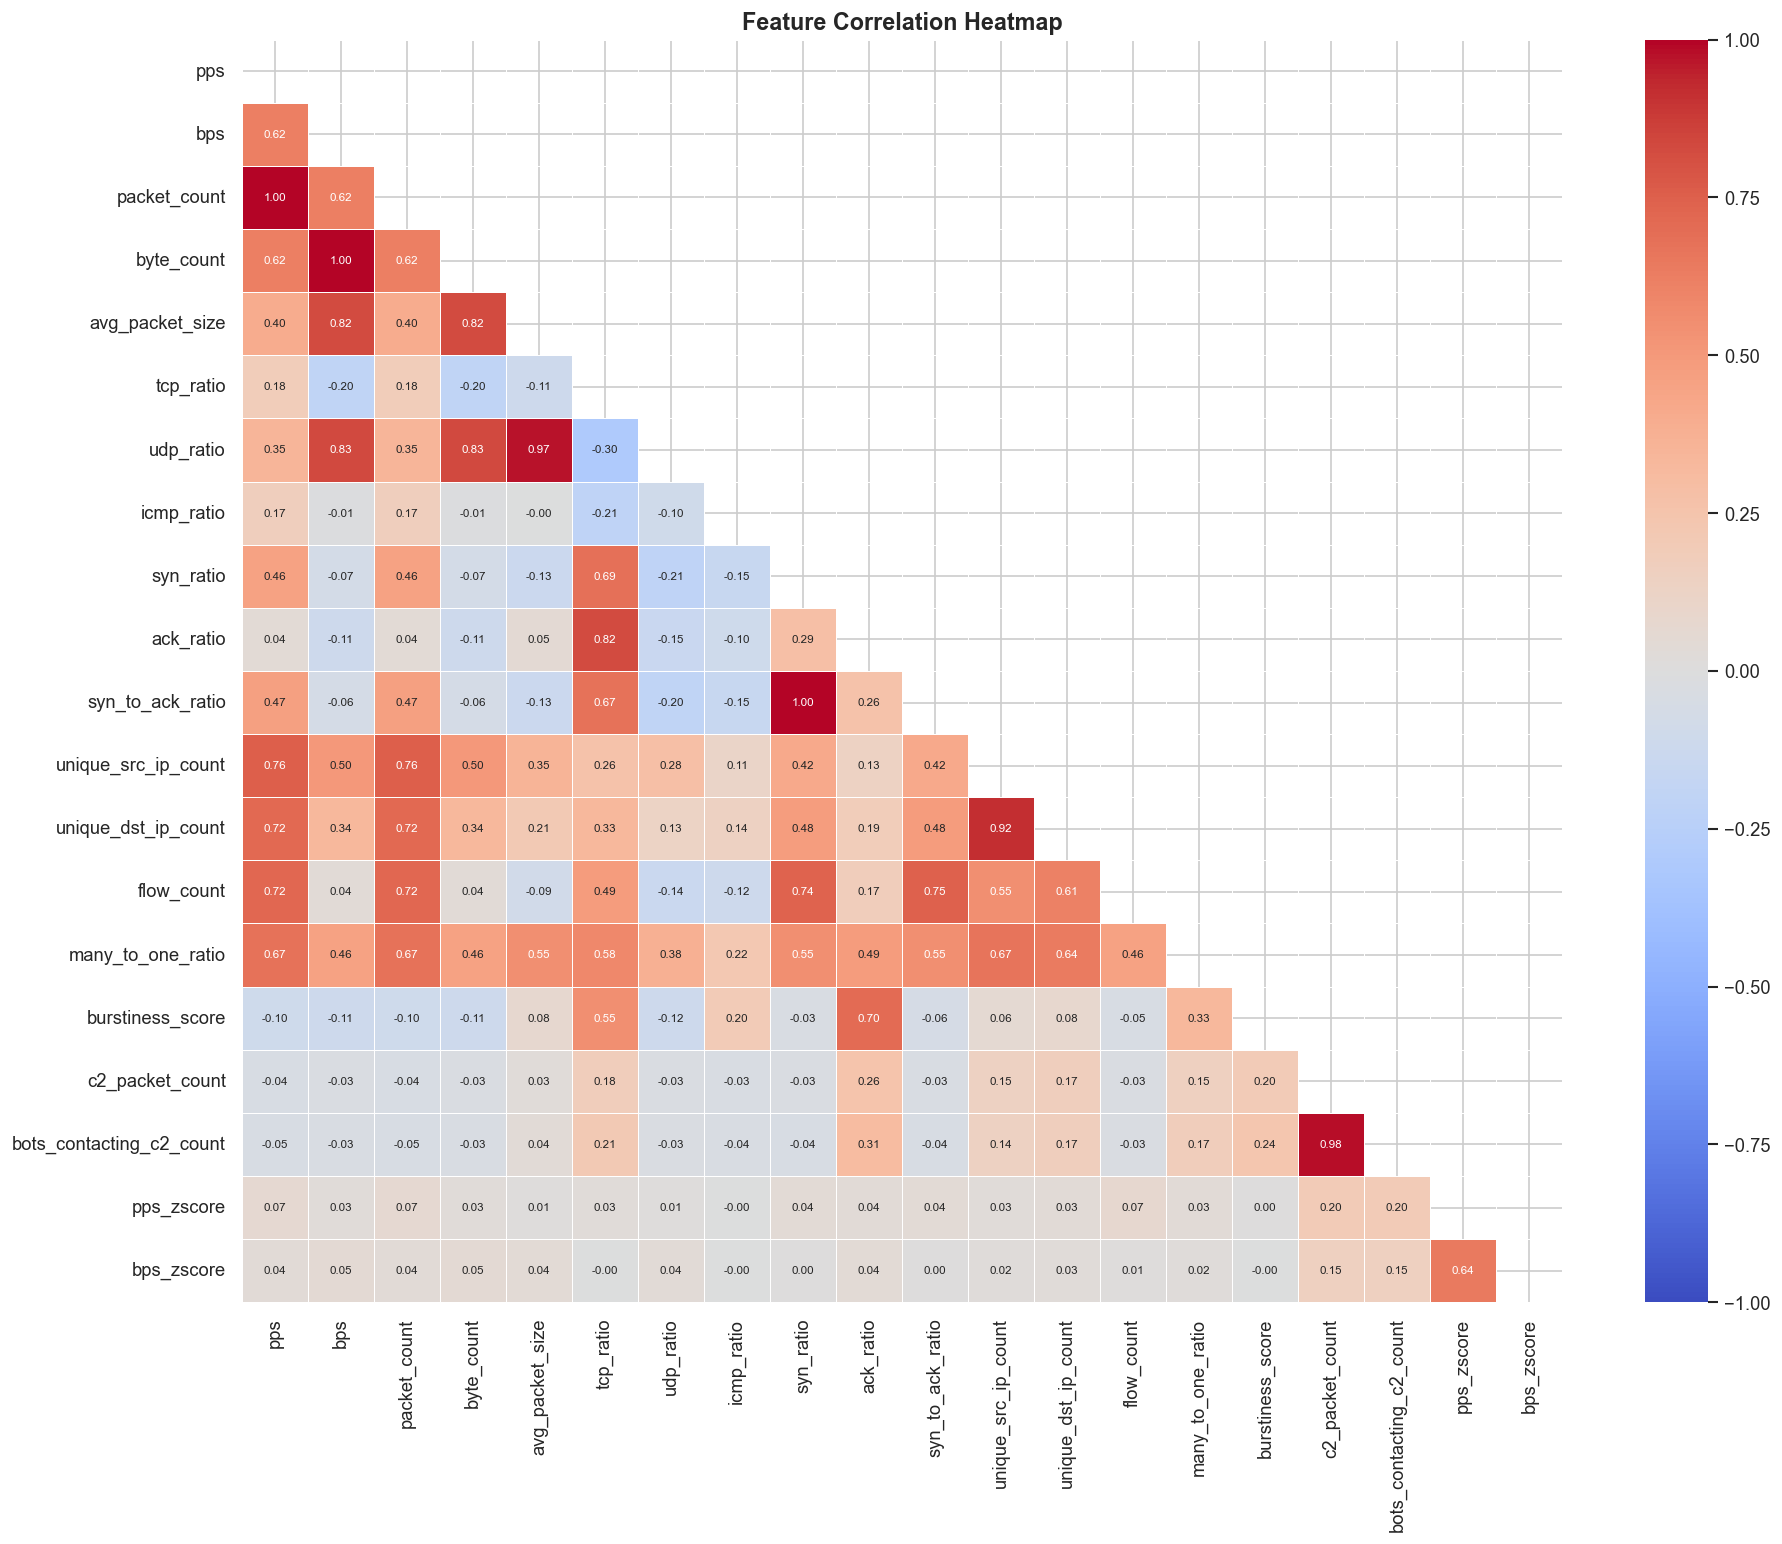

In [26]:
# ============================================================
# CELL 10 — Correlation heatmap (subset of meaningful features)
# ============================================================

CORR_FEATURES = [
    'pps', 'bps', 'packet_count', 'byte_count', 'avg_packet_size',
    'tcp_ratio', 'udp_ratio', 'icmp_ratio',
    'syn_ratio', 'ack_ratio', 'syn_to_ack_ratio',
    'unique_src_ip_count', 'unique_dst_ip_count',
    'flow_count', 'many_to_one_ratio',
    'burstiness_score', 'c2_packet_count',
    'bots_contacting_c2_count',
    'pps_zscore', 'bps_zscore',
]

corr_matrix = df[CORR_FEATURES].corr()

# Mask upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={'size': 7},
    ax=ax,
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
save(fig, 'correlation_heatmap.png')

---
## C2 Signal Analysis
C2 (Command & Control) features are unique to this dataset — they capture the coordination signals that bots use to launch a DDoS.  
We expect `bots_contacting_c2_count` and `c2_flow_count` to rise **before and during** the attack phase.

   Saved → c:\Users\pc\CNS_Project_C1\Behavioral-Analysis-and-Detection-of-Simulated-Botnet-Based-DDoS-Traffic\analysis\plots\c2_signals_by_phase.png


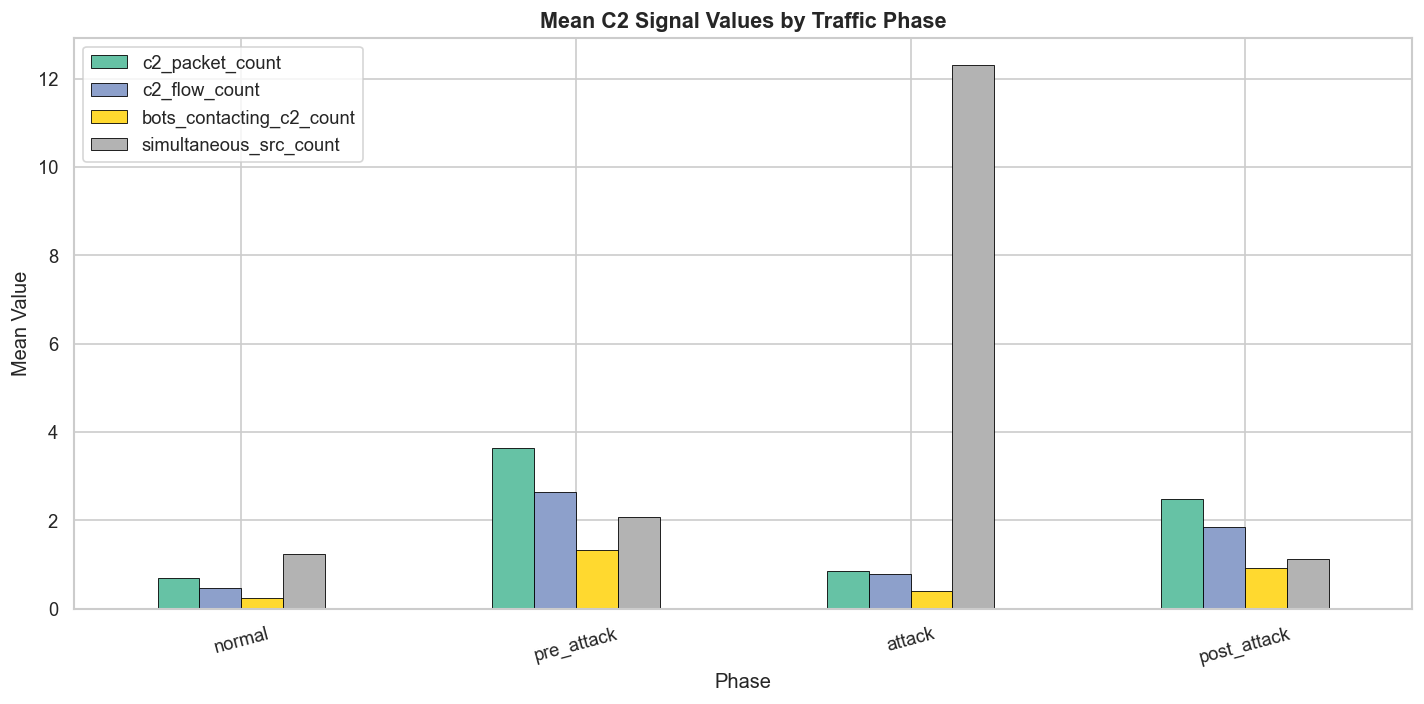

In [27]:
# ============================================================
# CELL 11 — C2 activity over phase
# ============================================================

c2_features = ['c2_packet_count', 'c2_flow_count',
               'bots_contacting_c2_count', 'simultaneous_src_count']

# Mean value per phase
c2_by_phase = df.groupby('phase')[c2_features].mean().reindex(phase_order)

c2_by_phase.plot(
    kind='bar',
    figsize=(12, 6),
    colormap='Set2',
    edgecolor='black',
    linewidth=0.5,
)
fig = plt.gcf()
plt.title('Mean C2 Signal Values by Traffic Phase', fontsize=13, fontweight='bold')
plt.xlabel('Phase')
plt.ylabel('Mean Value')
plt.xticks(rotation=15)
plt.legend(loc='upper left')
plt.tight_layout()
save(fig, 'c2_signals_by_phase.png')

---
## Burstiness Score Analysis
`burstiness_score` measures how 'spiky' traffic is within a window — high burstiness is a hallmark of flood attacks.  
We plot its distribution per phase and its scatter against pps.

   Saved → c:\Users\pc\CNS_Project_C1\Behavioral-Analysis-and-Detection-of-Simulated-Botnet-Based-DDoS-Traffic\analysis\plots\burstiness_analysis.png


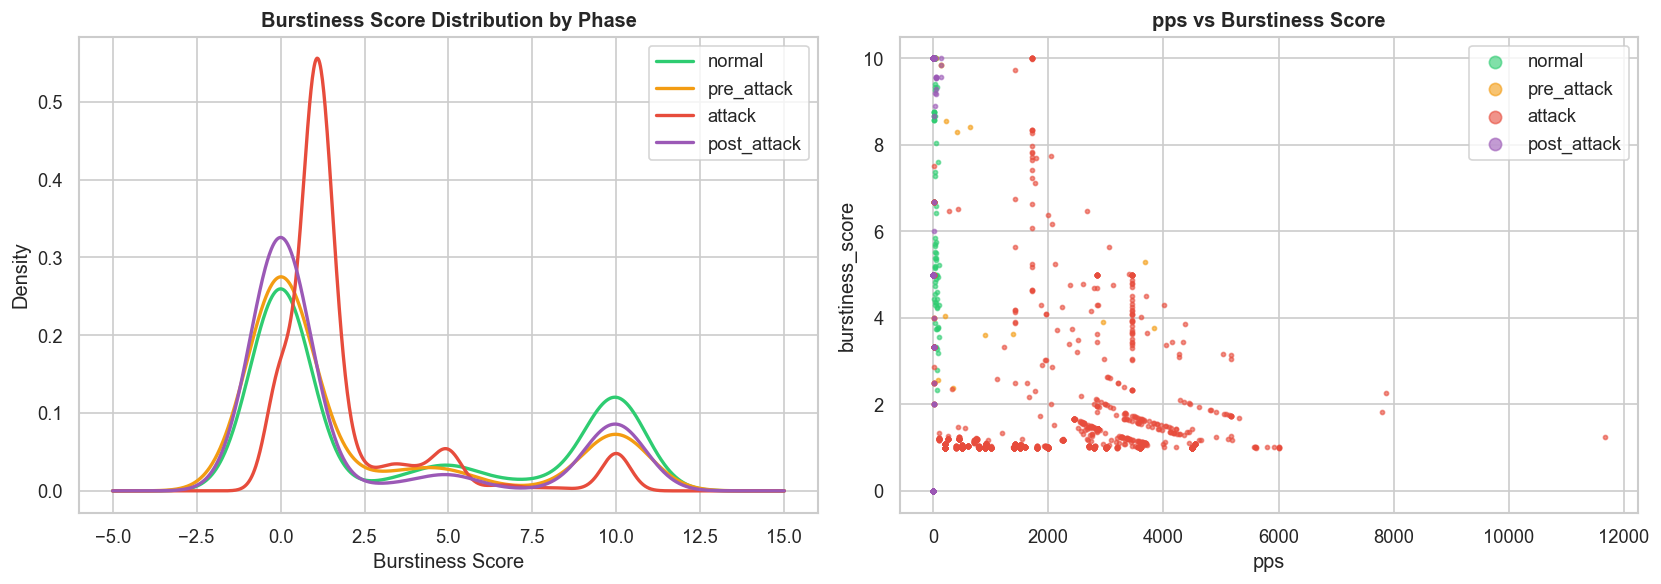

In [28]:
# ============================================================
# CELL 12 — Burstiness score deep-dive
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: KDE distribution per phase
for phase, colour in PHASE_COLOURS.items():
    subset = df[df['phase'] == phase]['burstiness_score']
    if subset.std() > 0:
        subset.plot.kde(ax=axes[0], label=phase, color=colour, linewidth=2)
axes[0].set_title('Burstiness Score Distribution by Phase', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Burstiness Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: Scatter pps vs burstiness, coloured by phase
sample = df.sample(min(3000, len(df)), random_state=42)
for phase, colour in PHASE_COLOURS.items():
    s = sample[sample['phase'] == phase]
    axes[1].scatter(s['pps'], s['burstiness_score'], c=colour, s=6,
                    alpha=0.6, label=phase)
axes[1].set_title('pps vs Burstiness Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('pps')
axes[1].set_ylabel('burstiness_score')
axes[1].legend(markerscale=3)

plt.tight_layout()
save(fig, 'burstiness_analysis.png')

---
## Rolling Statistics (5-second trends)
Features like `pps_slope_5s` (the trend of pps over the last 5 seconds) and `pps_zscore` (how abnormal pps is compared to recent history) can catch attacks that ramp up gradually.

   Saved → c:\Users\pc\CNS_Project_C1\Behavioral-Analysis-and-Detection-of-Simulated-Botnet-Based-DDoS-Traffic\analysis\plots\rolling_features_by_phase.png


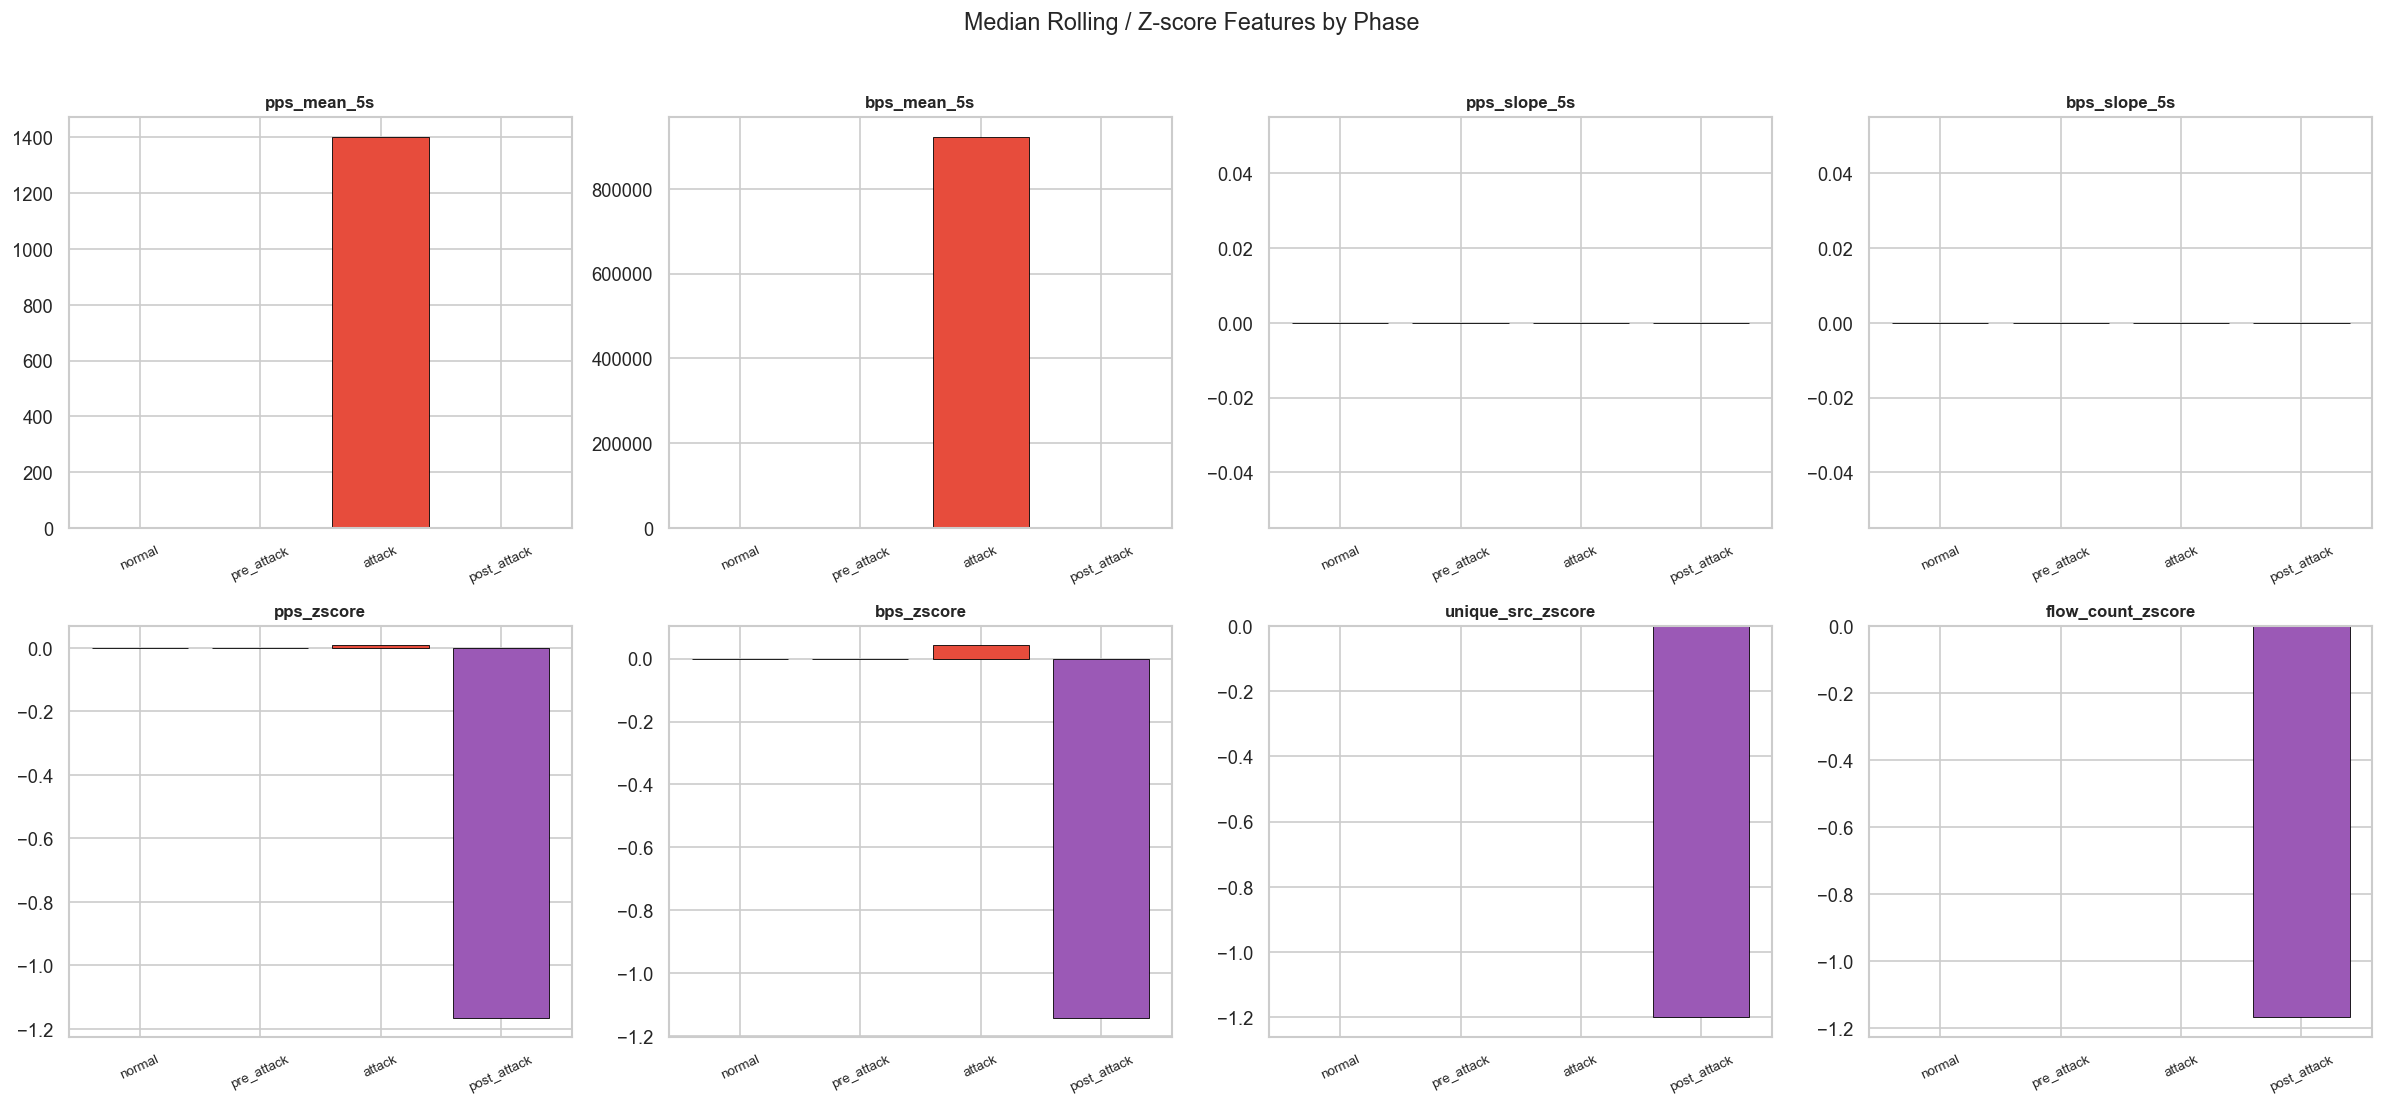

In [29]:
# ============================================================
# CELL 13 — Rolling statistics comparison
# ============================================================

roll_features = ['pps_mean_5s', 'bps_mean_5s',
                 'pps_slope_5s', 'bps_slope_5s',
                 'pps_zscore', 'bps_zscore',
                 'unique_src_zscore', 'flow_count_zscore']

roll_by_phase = df.groupby('phase')[roll_features].median().reindex(phase_order)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, feat in enumerate(roll_features):
    colours = [PHASE_COLOURS[p] for p in phase_order]
    axes[i].bar(phase_order, roll_by_phase[feat], color=colours, edgecolor='black',
                linewidth=0.5)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=25, labelsize=8)

plt.suptitle('Median Rolling / Z-score Features by Phase',
             fontsize=14, y=1.02)
plt.tight_layout()
save(fig, 'rolling_features_by_phase.png')

---
## Summary

| Plot saved | What it shows |
|---|---|
| `label_distributions.png` | Class balance across phase & attack_family |
| `pps_bps_over_time.png` | Traffic intensity time-series with phase shading |
| `feature_distributions_by_phase.png` | Box plots — key features per phase |
| `pps_unique_src_by_attack_family.png` | Attack family traffic signatures |
| `correlation_heatmap.png` | Pearson correlation between features |
| `c2_signals_by_phase.png` | C2 coordination activity per phase |
| `burstiness_analysis.png` | Burstiness distribution & pps scatter |
| `rolling_features_by_phase.png` | Trend & anomaly z-score features per phase |

### Key observations
- **pps** and **bps** rise sharply during the `attack` phase — the most obvious signal.
- **burstiness_score** and **syn_ratio** also spike during attacks, useful for detecting SYN floods specifically.
- **C2 features** (`bots_contacting_c2_count`, `c2_flow_count`) activate in `pre_attack` — they are early-warning signals.
- **pps_zscore / bps_zscore** allow context-aware detection even when absolute traffic volume is low.
- Many volume features (pps, bps, packet_count, byte_count) are highly correlated — a dimensionality-reduced model would work well.
